In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import numpy as np
import scipy

FONT_SIZE_TITLE=14
FONT_SIZE=12

## Single events analysis

In [2]:
conn = duckdb.connect("../results/results.duckdb")

In [3]:
conn.query("SELECT experiments.lakehouse, COUNT(events.*) AS events_consumed " \
"FROM experiments " \
"JOIN events ON events.experiment_id = experiments.id " \
"GROUP BY experiments.id, experiments.client, experiments.lakehouse " \
"ORDER BY experiments.id;")

┌─────────────────────┬─────────────────┐
│      lakehouse      │ events_consumed │
│       varchar       │      int64      │
├─────────────────────┼─────────────────┤
│ ducklake-0          │           30784 │
│ ducklake-1          │           28587 │
│ ducklake-2          │           28751 │
│ iceberg-0           │             824 │
│ iceberg-1           │             805 │
│ iceberg-2           │             806 │
│ ducklake-inlining-0 │           32207 │
│ ducklake-inlining-1 │           30742 │
│ ducklake-inlining-2 │           30935 │
│ iceberg-0           │            2481 │
│     ·               │              ·  │
│     ·               │              ·  │
│     ·               │              ·  │
│ iceberg-2           │          250853 │
│ ducklake-inlining-0 │          498964 │
│ ducklake-inlining-1 │          479460 │
│ ducklake-inlining-2 │          465000 │
│ iceberg-0           │          413650 │
│ iceberg-1           │          413706 │
│ iceberg-2           │          4

In [4]:
# FILE_NAME = "imgs/initial-thread-comparison.eps"

# events_consumed = conn.query("SELECT experiments.lakehouse, COUNT(events.*), experiments.client AS events_consumed " \
# "FROM experiments " \
# "JOIN events ON events.experiment_id = experiments.id " \
# "GROUP BY experiments.id, experiments.lakehouse, experiments.client;").fetchnumpy()

# plt.figure(figsize=(10,6))
# ax = plt.subplot()
# ax.set_title("Number of Kafka events written to each lakehouse after 1 minute, using 1 thread vs. 16 threads", pad=20.0)
# ax.set_xlabel("Lakehouse")
# ax.set_xticks(ticks=range(events_consumed["lakehouse"].size), labels=events_consumed["lakehouse"], rotation=45)
# ax.set_ylabel("No. of events written")
# sns.barplot(events_consumed, x="lakehouse", y="events_consumed", ax=ax, hue="client")
# ax.legend(title="Client")

# for container in ax.containers:
#     ax.bar_label(container)

# ax.set_xticks(range(len(events_consumed["lakehouse"])), events_consumed["lakehouse"])
# ax.set_xticklabels(events_consumed["lakehouse"])
# if not os.path.exists(FILE_NAME):
#     plt.savefig(FILE_NAME)
# plt.show()

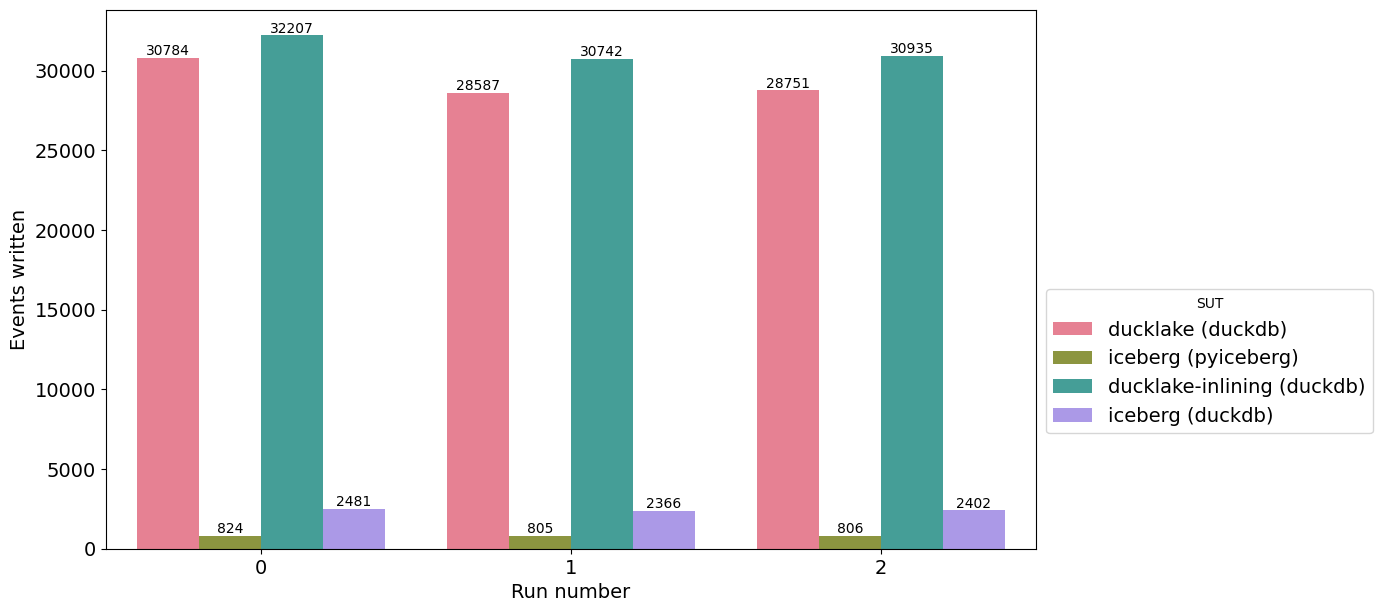

In [5]:
total_events_consumed_ids = [i for i in range(1,13)]

total_events_consumed = conn.query("SELECT concat(str_split_regex(experiments.lakehouse, '-[0-9]')[1], ' ', '(', experiments.client, ')') AS lakehouse, " \
                            "str_split_regex(experiments.lakehouse, '-')[-1] AS run_number, " \
                            "COUNT(events.*) AS events_consumed, " \
                            "experiments.client " \
                            "FROM experiments " \
                            "JOIN events ON events.experiment_id = experiments.id " \
                            f"WHERE id IN ({",".join(["?" for _ in range(len(total_events_consumed_ids))])})" \
                            "GROUP BY experiments.id, experiments.lakehouse, experiments.client " \
                            "ORDER BY experiments.id;", params=total_events_consumed_ids).fetchnumpy()

plt.figure(figsize=(12,7))
ax = plt.subplot()
# ax.set_title("Total number of Kafka events written to each lakehouse after 5 minutes, repeated 3 times", fontsize=FONT_SIZE_TITLE)
ax.set_xlabel("Run number", fontsize=FONT_SIZE+2)
ax.set_ylabel("Events written", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.barplot(total_events_consumed, x="run_number", y="events_consumed", hue="lakehouse", palette=sns.color_palette("husl", 4))
for container in ax.containers:
    ax.bar_label(container)
ax.legend(title="SUT", bbox_to_anchor=(1, 0.5), fontsize=FONT_SIZE+2)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/total-individual-events-written.eps", bbox_inches="tight")
plt.show()

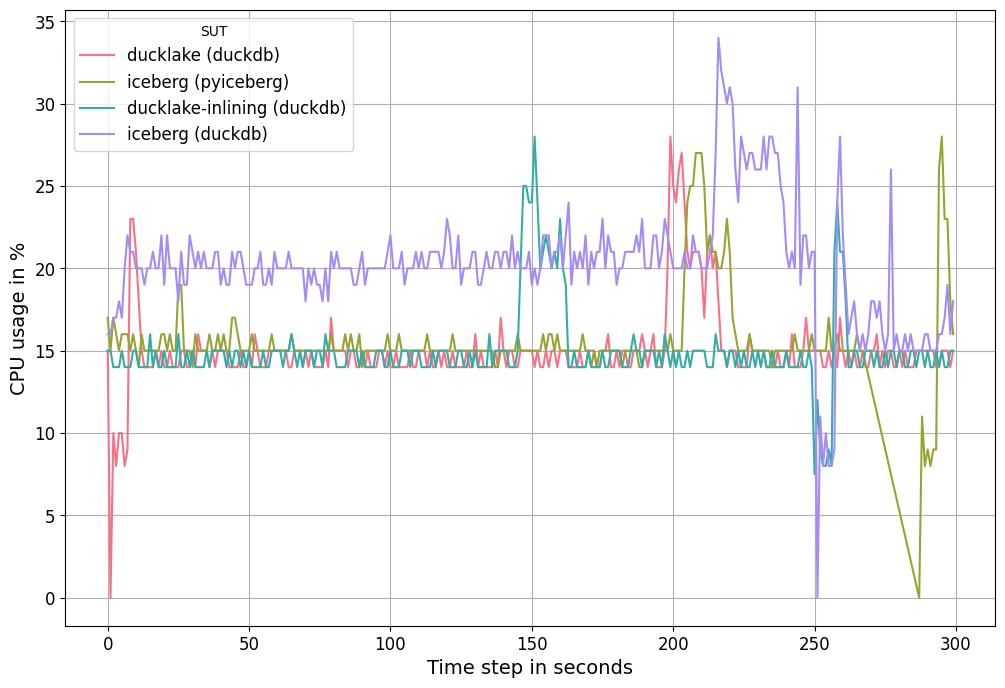

In [6]:
def get_cpu_percentage(experiment_ids: list[int]):
    return conn.query("SELECT h.id % 300 AS time_step," \
                        "concat(str_split_regex(e.lakehouse, '-[0-9]')[1], ' ', '(', e.client, ')') AS lakehouse, " \
                        "h.cpu_percentage, " \
                        "FROM hardware_metrics AS h " \
                        "JOIN experiments AS e ON e.id = h.experiment_id " \
                        f"WHERE experiment_id IN ({",".join(["?" for _ in range(len(experiment_ids))])});", params=experiment_ids).fetchnumpy()

plt.figure(figsize=(12,8))
ax = plt.subplot()
ax.grid(visible=True)
ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
ax.set_xlabel("Time step in seconds", fontsize=FONT_SIZE+2)
ax.set_ylabel("CPU usage in %", fontsize=FONT_SIZE+2)
sns.lineplot(get_cpu_percentage([2,5,8,11]), x="time_step", y="cpu_percentage", hue="lakehouse", ax=ax, palette=sns.color_palette("husl", 4))
plt.legend(loc="best", title="SUT", fontsize=FONT_SIZE)
# sns.lineplot(get_hardware_metrics(4), x="time_step", y="cpu_percentage", ax=ax)
# sns.lineplot(get_hardware_metrics(7), x="time_step", y="cpu_percentage", ax=ax)
# sns.lineplot(get_hardware_metrics(12), x="time_step", y="cpu_percentage", ax=ax)
# sns.lineplot(get_hardware_metrics(3), x="time_step", y="cpu_percentage", ax=ax)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/cpu-usage-individual-events.eps", bbox_inches="tight")
plt.show()

## Plot bytes written

In [7]:
def get_bytes_written(experiment_ids: list[int]):
    return conn.query("SELECT h.id % 300 AS time_step, " \
                        "e.id AS experiment_id, " \
                        "concat(str_split_regex(e.lakehouse, '-[0-9]')[1], ' ', '(', e.client, ')') AS lakehouse, " \
                        "COALESCE(h.bytes_written - LAG(h.bytes_written) OVER (ORDER BY h.id), 0) AS bytes_written_clean," \
                        "FROM hardware_metrics as h " \
                        "JOIN experiments AS e ON e.id = h.experiment_id " \
                        f"WHERE experiment_id IN ({",".join(["?" for _ in range(len(experiment_ids))])}) " \
                        "ORDER BY experiment_id;", params=experiment_ids).fetchnumpy()

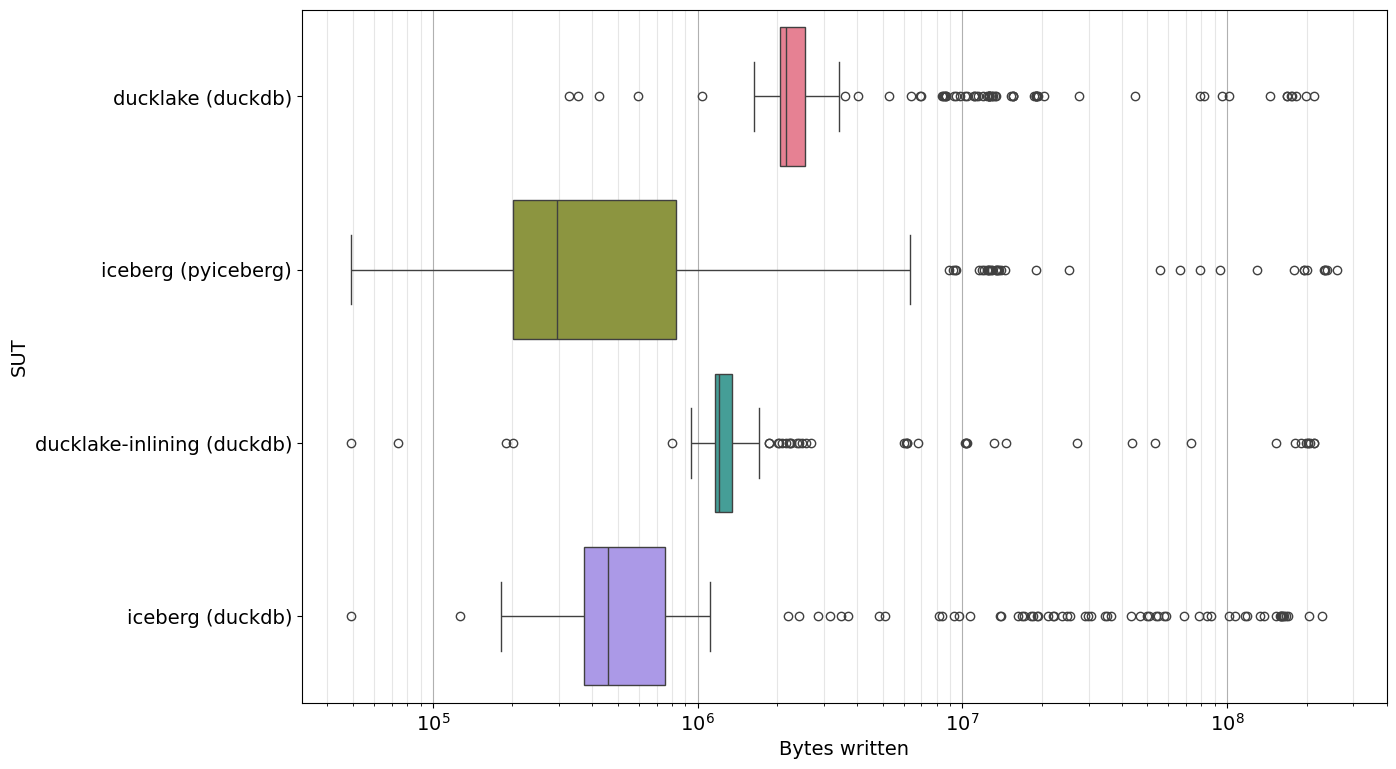

In [8]:
bytes_written_experiment_ids = [2,5,8,11]
# bytes_written_experiment_ids = [1,4,7,10]
# bytes_written_experiment_ids = [3,6,9,12]
bytes_written = get_bytes_written(bytes_written_experiment_ids)

plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Boxplot of bytes written to disk at every second when inserting individual events to each SUT (warm run)", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Bytes written", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
# ax.tick_params(axis="y", labelrotation=30)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
sns.boxplot(bytes_written, x="bytes_written_clean", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", len(bytes_written_experiment_ids)), ax=ax, log_scale=True)
# plt.legend(loc="best", title="SUT", bbox_to_anchor=(1, 0.5), fontsize=FONT_SIZE)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-bytes-written-individual.eps", bbox_inches="tight")

plt.show()

In [9]:
def calculate_outliers(arr: np.array) -> tuple[np.array, np.array]:
    iqr = scipy.stats.iqr(arr)
    lower_bound = np.subtract(np.percentile(arr, 25), np.multiply(1.5,iqr))
    upper_bound = np.add(np.percentile(arr, 75), np.multiply(1.5,iqr))
    return arr[(arr > lower_bound) & (arr < upper_bound)]

In [10]:
bytes_data = get_bytes_written([8])["bytes_written_clean"]
calculate_outliers(bytes_data).size, bytes_data.size

(255, 301)

### Medians

In [11]:
experiment_ids = bytes_written["experiment_id"]
ducklake_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 2])
iceberg_py_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 5])
ducklake_in_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 8])
iceberg_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 11])

np.format_float_scientific(ducklake_duck_median), np.format_float_scientific(iceberg_py_median), np.format_float_scientific(ducklake_in_median), np.format_float_scientific(iceberg_duck_median)

('2.154496e+06', '2.90816e+05', '1.204224e+06', '4.58752e+05')

In [12]:
experiment_ids = bytes_written["experiment_id"]
ducklake_duck_mad = scipy.stats.median_abs_deviation(bytes_written["bytes_written_clean"][experiment_ids == 2])
iceberg_py_mad = scipy.stats.median_abs_deviation(bytes_written["bytes_written_clean"][experiment_ids == 5])
ducklake_in_mad = scipy.stats.median_abs_deviation(bytes_written["bytes_written_clean"][experiment_ids == 8])
iceberg_duck_mad = scipy.stats.median_abs_deviation(bytes_written["bytes_written_clean"][experiment_ids == 11])

np.format_float_scientific(ducklake_duck_mad), np.format_float_scientific(iceberg_py_mad), np.format_float_scientific(ducklake_in_mad), np.format_float_scientific(iceberg_duck_mad)

('1.4336e+05', '1.18784e+05', '6.9632e+04', '1.10592e+05')

### Interquartile ranges

In [13]:
experiment_ids = bytes_written["experiment_id"]
ducklake_duck_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 2])
iceberg_py_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 5])
ducklake_in_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 8])
iceberg_duck_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 11])

np.format_float_scientific(ducklake_duck_iqr), np.format_float_scientific(iceberg_py_iqr), np.format_float_scientific(ducklake_in_iqr), np.format_float_scientific(iceberg_duck_iqr)

('5.0176e+05', '5.9392e+05', '1.92512e+05', '3.79904e+05')

## Plot read and write times

In [14]:
def get_read_and_write_times(experiment_ids: list[int]):
    return conn.query("SELECT ev.trip_id, " \
                        "ex.id AS experiment_id, " \
                        "concat(str_split_regex(ex.lakehouse, '-[0-9]')[1], ' ', '(', ex.client, ')') AS lakehouse, " \
                        "ev.read_duration_ns/1e9 AS read_time, " \
                        "ev.write_duration_ns/1e9 AS write_time " \
                        "FROM events AS ev " \
                        "JOIN experiments AS ex ON ex.id = ev.experiment_id " \
                        f"WHERE ex.id IN ({",".join(["?" for _ in range(len(experiment_ids))])}) " \
                        "ORDER BY ex.id;", params=experiment_ids).fetchnumpy()

read_and_write_times = get_read_and_write_times([2,5,8,11])

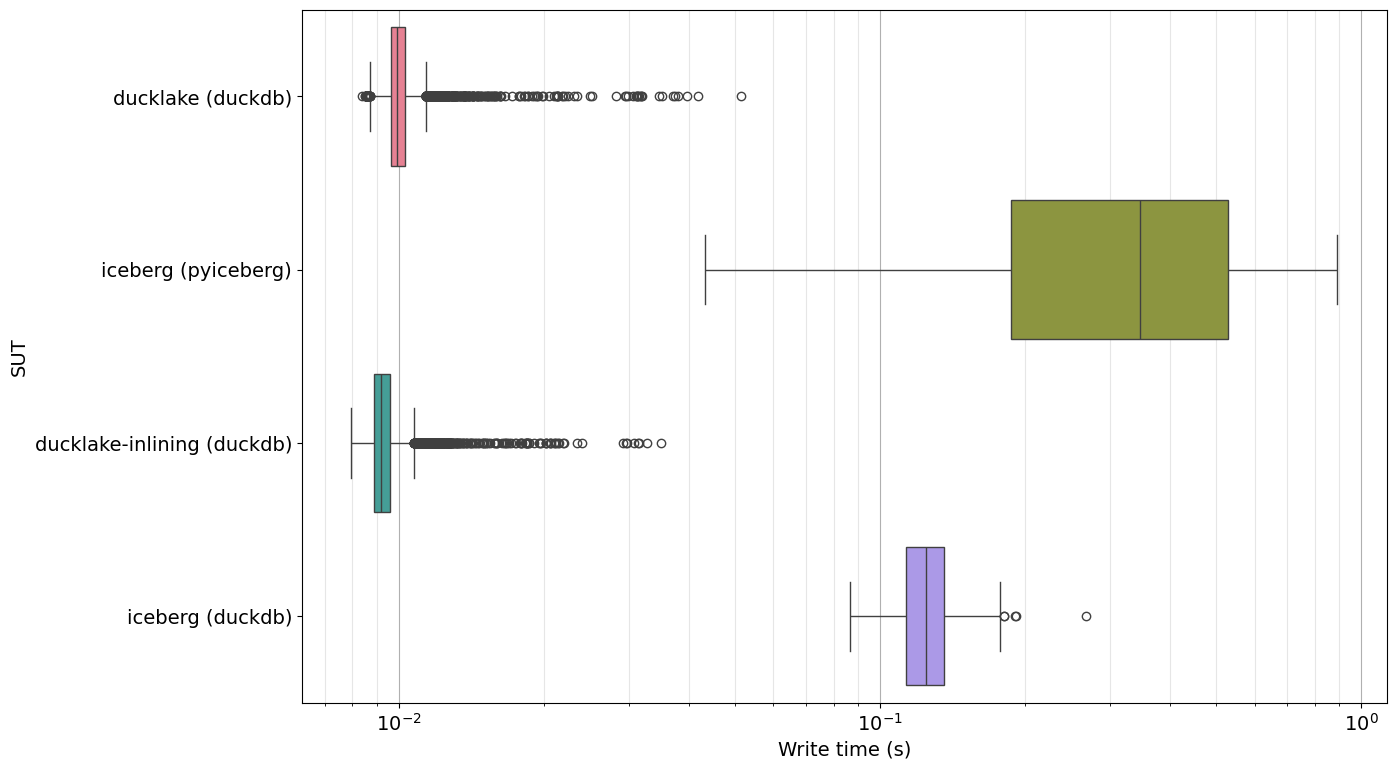

In [ ]:
plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Box plots of the time spent writing individual events for each SUT, in seconds", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Write time (s)", fontsize=FONT_SIZE+2)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.boxplot(read_and_write_times, x="write_time", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", 4), ax=ax, log_scale=True)
# ax.legend(loc="best", title="SUT", fontsize=FONT_SIZE+2)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-write-times-individual.eps", bbox_inches="tight")
plt.show()

### Median

In [16]:
# experiment_ids = read_and_write_times["experiment_id"]
# ducklake_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 2])
# iceberg_py_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 5])
# ducklake_in_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 8])
# iceberg_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 11])

(np.format_float_scientific(np.median(get_read_and_write_times([2])["write_time"])),
 np.format_float_scientific(np.median(get_read_and_write_times([5])["write_time"])),
 np.format_float_scientific(np.median(get_read_and_write_times([8])["write_time"])),
 np.format_float_scientific(np.median(get_read_and_write_times([11])["write_time"])),
)

('9.888885e-03', '3.46208303e-01', '9.1688675e-03', '1.243029755e-01')

### Interquartile range

In [17]:
(np.format_float_scientific(scipy.stats.iqr(get_read_and_write_times([2])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_read_and_write_times([5])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_read_and_write_times([8])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_read_and_write_times([11])["write_time"])),
)

('6.671820000000005e-04',
 '3.4119407300000004e-01',
 '7.112917500000007e-04',
 '2.2650175750000015e-02')

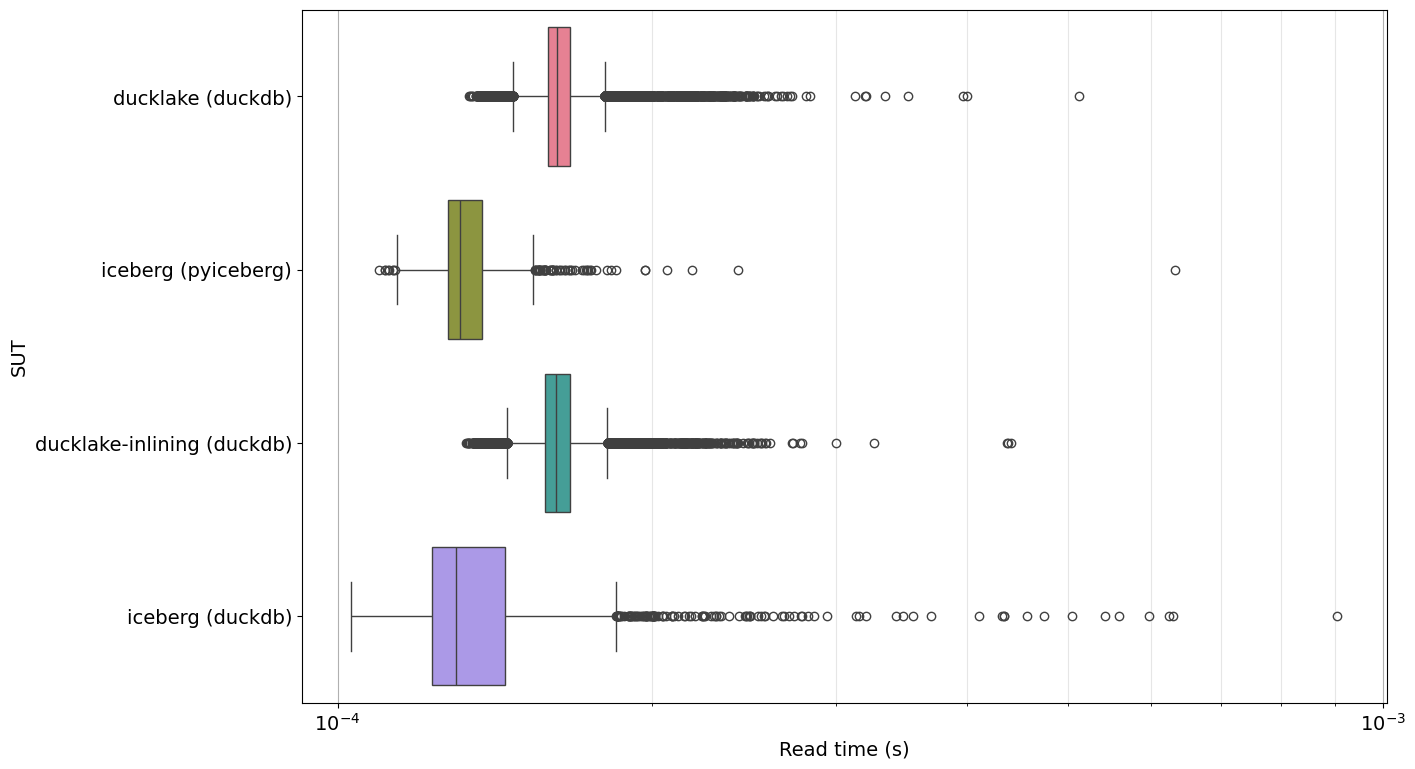

In [18]:
plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Box plots of the time spent reading individual events from Kafka before inserting them to the SUT, in seconds", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Read time (s)", fontsize=FONT_SIZE+2)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.boxplot(read_and_write_times, x="read_time", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", 4), ax=ax, log_scale=True)
# ax.legend(title="SUT", fontsize=FONT_SIZE+2)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-read-times-individual.eps", bbox_inches="tight")
plt.show()

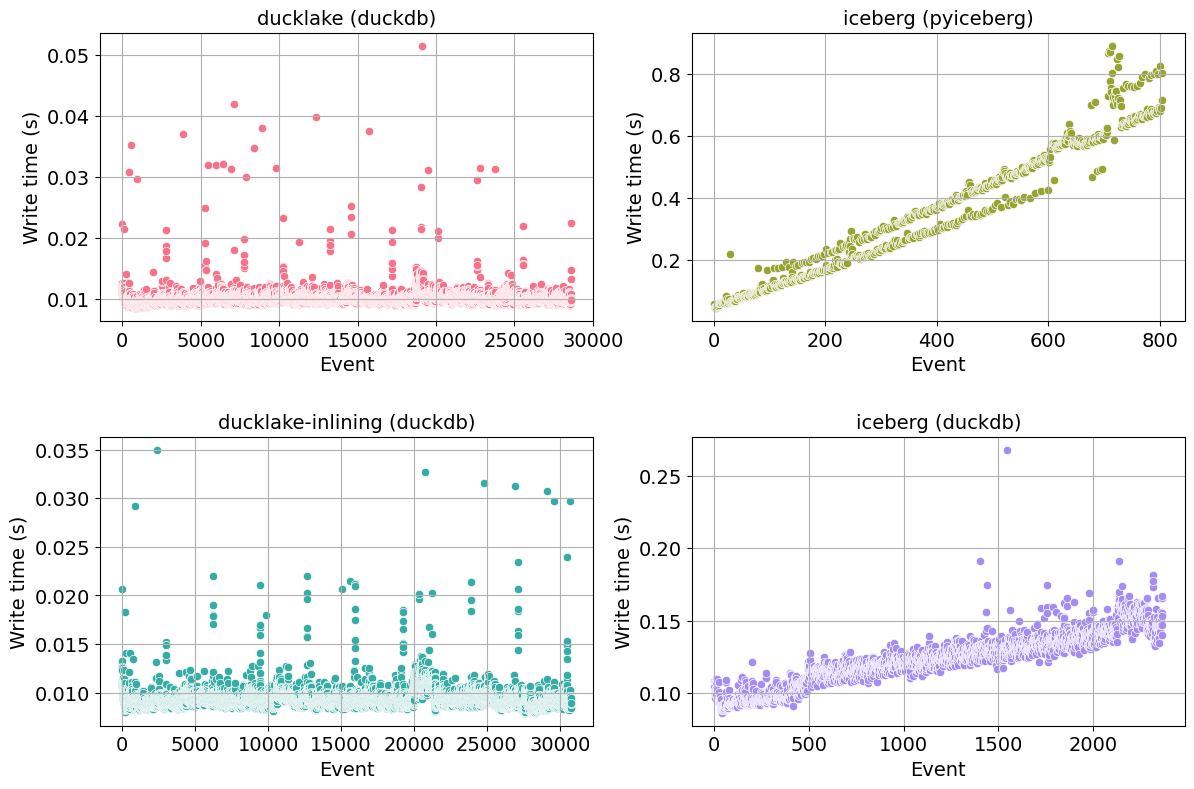

In [19]:
color_palette = sns.color_palette("husl", 4)
# plt.figure(figsize=(30,15))
fig, ax = plt.subplots(2,2,figsize=(14,9))
plt.subplots_adjust(hspace=0.4)
# write_time_comp = [get_read_and_write_times([i]) for i in range(2,12,3)]
# fig.suptitle("Time spent writing each event to DuckLake (top) and Iceberg (bottom) in seconds", fontsize=FONT_SIZE_TITLE+2)
for i, (axis, experiment_id) in enumerate(zip(ax.flatten(), np.unique(read_and_write_times["experiment_id"], sorted=True))):
    axis.grid()
    axis.set_xlabel("Event", fontsize=FONT_SIZE+2)
    axis.set_ylabel("Write time (s)", fontsize=FONT_SIZE+2)
    axis.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
    exp_data = get_read_and_write_times([int(experiment_id)])
    sns.scatterplot(exp_data, x="trip_id", y="write_time", color=color_palette[i], ax=axis)
    axis.set_title(np.unique(exp_data["lakehouse"])[0], fontsize=FONT_SIZE+2)

# ax.set_yscale("log")
# sns.scatterplot(read_and_write_ducklake, x="trip_id", y="write_time", facecolor=color_palette[0], ax=ax[0])
# sns.scatterplot(read_and_write_iceberg, x="trip_id", y="write_time", facecolor=color_palette[1], ax=ax[1])
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/scatter-write-times-over-time-individual.eps", bbox_inches="tight")
plt.show()

### Inlining

In [20]:
conn.query("SELECT flush_inlined_duration/1e9 FROM experiments WHERE lakehouse LIKE 'ducklake-inlining%';")

┌─────────────────────────────────────────┐
│ (flush_inlined_duration / 1000000000.0) │
│                 double                  │
├─────────────────────────────────────────┤
│                             0.219873987 │
│                               0.2058669 │
│                             0.193615275 │
│                             0.048235798 │
│                             0.049763229 │
│                             0.049418538 │
│                             0.002155011 │
│                             0.012775413 │
│                              0.01681532 │
│                             2.286785947 │
│                             1.992167419 │
│                             1.973862601 │
├─────────────────────────────────────────┤
│                 12 rows                 │
└─────────────────────────────────────────┘

In [21]:
def calculate_ci(data: np.array):
    return np.subtract(data.mean(),np.multiply(0.95,np.divide(data.std(),np.sqrt(data.size)))), np.add(data.mean(),np.multiply(0.95,np.divide(data.std(),np.sqrt(data.size))))

def replicate_sampling(arr: np.array, repetitions: int, func, sample_size: float):
    return np.array([func(np.random.choice(arr,size=int(arr.size*sample_size),replace=True)) for _ in range(repetitions)])
        

In [22]:
np.std(get_read_and_write_times([4])["write_time"]),np.std(get_read_and_write_times([5])["write_time"]),np.std(get_read_and_write_times([6])["write_time"]),

(np.float64(0.19564920351226342),
 np.float64(0.20600526895780794),
 np.float64(0.20392340187517202))